In [2]:
%load_ext autoreload
%autoreload 2


import scanpy as sc
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from diptest import diptest
import scvi
from dotenv import load_dotenv; load_dotenv()
import os
import glob
import pandas as pd

from utils import preprocessing

# Hyperparamyters
BASE_PATH = os.getenv("BASE_PATH_FOR_SAVING")
print(f"BASE_PATH: {BASE_PATH}")


BASE_PATH: /home/gdallagl/myworkdir/data/XDP


# Find and Load all Libraries (H+D)

In [2]:
adatas = []

for path in sorted(glob.glob(f"{BASE_PATH}/SlideTags_single_libraries/*/*/*/adata/doublets_filtered_adata.h5ad")):
    
    # Parse metadata from path: BASE/disease_type/sample_id/BCL/library/adata/file
    parts = path.replace(BASE_PATH + "/", "").split("/")
    sample_id, bcl, library = parts[1], parts[2], parts[3]
    
    print(f"Loading: {sample_id}/{library}")
    adata = sc.read_h5ad(path)
    display(adata)

    ###Create minimal adata

    # 1. fitler same obs
    adata.obs = adata.obs[['x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', "sample",
                           
                           'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 
                           'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 
                           'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability',
                           'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability',
                           'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability',

                           'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 
                           
                           ]]

    # 2. same infos
    adata.var    = adata.var[['feature_types', 'genome', 'gene_symbol']]
    adata.obsm   = {k: adata.obsm[k].copy()   for k in ('spatial',) if k in adata.obsm}
    adata.layers = {k: adata.layers[k].copy() for k in ('counts',)  if k in adata.layers}
    
    # Add per-library metadata
    assert adata.obs["sample"].unique()[0] == sample_id # needed for join 
    adata.obs["library_id"] = bcl + "_" + library

    # make cell index unique
    adata.obs_names = bcl + "---" + library + "---" + adata.obs_names.astype(str)

    # restart from raw counts
    adata.X = adata.layers["counts"].copy()
    
    adatas.append(adata)

print(f"\nLoaded {len(adatas)} libraries")


Loading: sample_01/SI-TT-H1


AnnData object with n_obs × n_vars = 30678 × 38606
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'sample', 'has_spatial', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Class_correlation_coefficient', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Subclass_correlation_coefficient', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Group_correlation_coefficient', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'Cluster_aggregate_probability', 'Cluster_correlation_coefficient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_10

Loading: sample_01/SI-TT-H2


AnnData object with n_obs × n_vars = 29613 × 38606
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'sample', 'has_spatial', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Class_correlation_coefficient', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Subclass_correlation_coefficient', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Group_correlation_coefficient', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'Cluster_aggregate_probability', 'Cluster_correlation_coefficient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_10

Loading: sample_01/SI-TT-H3


...

Loading: sample_09/SI-TT-E7


AnnData object with n_obs × n_vars = 16330 × 38606
    obs: 'x', 'y', 'pct_intronic', 'frac_contamination', 'dbscan_clusters', 'dbscan_score', 'sample', 'has_spatial', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Class_correlation_coefficient', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Subclass_correlation_coefficient', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Group_correlation_coefficient', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'Cluster_aggregate_probability', 'Cluster_correlation_coefficient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',

Loading: sample_09/SI-TT-E8


AnnData object with n_obs × n_vars = 16804 × 38606
    obs: 'x', 'y', 'pct_intronic', 'frac_contamination', 'dbscan_clusters', 'dbscan_score', 'sample', 'has_spatial', 'Neighborhood_label', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Neighborhood_correlation_coefficient', 'Class_label', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Class_correlation_coefficient', 'Subclass_label', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Subclass_correlation_coefficient', 'Group_label', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Group_correlation_coefficient', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'Cluster_aggregate_probability', 'Cluster_correlation_coefficient', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',


Loaded 37 libraries


# Check gene overlap

they soudl eb ll the same:
- no gene remvoel before this point
- used same ref in cellrnager

In [3]:
gene_sets = [set(a.var_names) for a in adatas]
inner = gene_sets[0].intersection(*gene_sets[1:])
outer = gene_sets[0].union(*gene_sets[1:])

print(f"N libraries:           {len(adatas)}")
print(f"INNER join (common):   {len(inner):,} genes")
print(f"OUTER join (union):    {len(outer):,} genes")
print(f"Genes lost vs outer:   {len(outer) - len(inner):,}")
print()
for i, (a, gs) in enumerate(zip(adatas, gene_sets)):
    sample = a.obs['sample'].iloc[0]
    print(f"  lib {i+1} ({sample}): {len(gs):,} genes  |  unique to this lib: {len(gs - inner):,}")


N libraries:           37
INNER join (common):   38,606 genes
OUTER join (union):    38,606 genes
Genes lost vs outer:   0

  lib 1 (sample_01): 38,606 genes  |  unique to this lib: 0
  lib 2 (sample_01): 38,606 genes  |  unique to this lib: 0
  lib 3 (sample_01): 38,606 genes  |  unique to this lib: 0
  lib 4 (sample_02): 38,606 genes  |  unique to this lib: 0
  lib 5 (sample_02): 38,606 genes  |  unique to this lib: 0
  lib 6 (sample_02): 38,606 genes  |  unique to this lib: 0
  lib 7 (sample_02): 38,606 genes  |  unique to this lib: 0
  lib 8 (sample_03): 38,606 genes  |  unique to this lib: 0
  lib 9 (sample_03): 38,606 genes  |  unique to this lib: 0
  lib 10 (sample_03): 38,606 genes  |  unique to this lib: 0
  lib 11 (sample_03): 38,606 genes  |  unique to this lib: 0
  lib 12 (sample_04): 38,606 genes  |  unique to this lib: 0
  lib 13 (sample_04): 38,606 genes  |  unique to this lib: 0
  lib 14 (sample_04): 38,606 genes  |  unique to this lib: 0
  lib 15 (sample_04): 38,606 ge

# Concatenate

**ATTENTION**: how to join genes

In [4]:
# Save var info from FISRT dataset before concat

JOIN_GENE_MODALITY = "inner"

# # FOR INNER JOIN
if JOIN_GENE_MODALITY == "inner":
    var_info = adatas[0].var[['feature_types', 'genome', 'gene_symbol']].copy()

# FOR OUTER JOIN
if JOIN_GENE_MODALITY == "outer":
    var_info = pd.concat([
        a.var[['feature_types', 'genome', 'gene_symbol']]
        for a in adatas
    ]).groupby(level=0).first()  # deduplicate gene entries, keep first occurrence

# Concate
adata = sc.concat(adatas, 
                  
                # Not aligned to the concatenation axis (i.e., things in .uns, .var, .varm, .obsm, etc.) are selected/combined
                  
                # No need as we make barcodes ouqnie before
                #   index_unique='-',
                #   keys=LIBRARIES, # add to the obs_name the library name as prefix, separated by "index unique"

                join=JOIN_GENE_MODALITY
)  # keeps COMMON genes
del adatas

# Restore var info for common genes
adata.var = var_info.loc[adata.var_names]

# ATTENTION : now same genes coild be no more expressed
sc.pp.filter_genes(adata, min_cells=3)

print(adata)
display(adata.obs.head(3))
display(adata.var.head(3))
assert adata.obs_names.is_unique, "ERROR: adata.obs_names are not unique!"
assert adata.var_names.is_unique, "ERROR: adata.var_names are not unique!"



AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id'
    var: 'feature_types', 'genome', 'gene_symbol', 'n_cells'
    obsm: 'spatial'
    layers: 'counts'


,x,y,pct_intronic,dbscan_clusters,dbscan_score,has_spatial,sample,Neighborhood_name,Neighborhood_bootstrapping_probability,Neighborhood_aggregate_probability,...,Cluster_alias,Cluster_bootstrapping_probability,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,library_id
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGATAACAG-1,33013.428400,444.562211,0.585746,3.0,0.230731,False,sample_01,Nonneuron,1.0,1.0,...,Human-230,1.00,3675,8.209580,7489,8.921324,21,3.091042,0.280411,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGCATGGAG-1,21225.159553,4193.340108,0.596834,1.0,0.942997,True,sample_01,Nonneuron,1.0,1.0,...,Human-532,0.41,2180,7.687539,4352,8.378621,3,1.386294,0.068934,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGGCGGAGT-1,16429.015488,3852.143369,0.716821,1.0,0.936590,True,sample_01,Nonneuron,1.0,1.0,...,Human-15,1.00,2406,7.786136,6496,8.779096,0,0.000000,0.000000,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1


,feature_types,genome,gene_symbol,n_cells
ensembl_id,,,,
ENSG00000290825,Gene Expression,GRCh38,DDX11L2,134
ENSG00000243485,Gene Expression,GRCh38,MIR1302-2HG,641
ENSG00000290826,Gene Expression,GRCh38,ENSG00000290826,94


# Add Metadata

In [5]:
adata.obs

,x,y,pct_intronic,dbscan_clusters,dbscan_score,has_spatial,sample,Neighborhood_name,Neighborhood_bootstrapping_probability,Neighborhood_aggregate_probability,...,Cluster_alias,Cluster_bootstrapping_probability,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,library_id
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGATAACAG-1,33013.428400,444.562211,0.585746,3.0,0.230731,False,sample_01,Nonneuron,1.0,1.0,...,Human-230,1.00,3675,8.209580,7489,8.921324,21,3.091042,0.280411,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGCATGGAG-1,21225.159553,4193.340108,0.596834,1.0,0.942997,True,sample_01,Nonneuron,1.0,1.0,...,Human-532,0.41,2180,7.687539,4352,8.378621,3,1.386294,0.068934,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGGCGGAGT-1,16429.015488,3852.143369,0.716821,1.0,0.936590,True,sample_01,Nonneuron,1.0,1.0,...,Human-15,1.00,2406,7.786136,6496,8.779096,0,0.000000,0.000000,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGGTCTATG-1,43242.438818,-1822.457007,0.609493,0.0,0.366933,False,sample_01,Nonneuron,1.0,1.0,...,Human-159,0.98,827,6.719013,1710,7.444833,0,0.000000,0.000000,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
251027_SL-EXD_0706_A233KGFLT4---SI-TT-H1---AAACCAAAGGTTGTAT-1,14118.369028,-4852.270550,0.588186,1.0,0.859807,True,sample_01,Nonneuron,1.0,1.0,...,Human-1,1.00,1808,7.500529,4185,8.339501,4,1.609438,0.095579,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240911_SL-EXD_0362_A22FLV2LT4---SI-TT-E8---GTTGTGCAGGCTAACC-1,2.428564,-9.834018,0.688042,1.0,0.858442,True,sample_09,Nonneuron,1.0,1.0,...,Human-543,0.77,1813,7.503290,3521,8.166784,1,0.693147,0.028401,240911_SL-EXD_0362_A22FLV2LT4_SI-TT-E8
240911_SL-EXD_0362_A22FLV2LT4---SI-TT-E8---GTTGTGGGTACTCGAG-1,8.858347,20.443236,0.662874,1.0,0.912978,True,sample_09,Subpallium GABA,1.0,1.0,...,Human-42,1.00,9431,9.151863,58731,10.980740,139,4.941642,0.236672,240911_SL-EXD_0362_A22FLV2LT4_SI-TT-E8
240911_SL-EXD_0362_A22FLV2LT4---SI-TT-E8---GTTGTGGGTGCAATGT-1,-15.850641,19.053723,0.684594,1.0,0.927349,True,sample_09,Nonneuron,1.0,1.0,...,Human-1,1.00,1765,7.476472,4173,8.336630,2,1.098612,0.047927,240911_SL-EXD_0362_A22FLV2LT4_SI-TT-E8
240911_SL-EXD_0362_A22FLV2LT4---SI-TT-E8---GTTGTGGGTGTGTGAT-1,4.130035,16.020621,0.617324,2.0,0.287954,False,sample_09,Nonneuron,1.0,1.0,...,Human-1,1.00,3230,8.080547,8976,9.102421,30,3.433987,0.334225,240911_SL-EXD_0362_A22FLV2LT4_SI-TT-E8


In [6]:
df_meta = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/SlideTags_XDP_metadata/XDP Slidetags - CellBender Terra table - cb.csv")
display(df_meta.columns)

df_meta = df_meta[["entity:library_id", "donor_number", "donor_id", "condition", "sex", "age_at_onset", "age_at_death", "bcl", "RNAindex", "Sorted"]]
df_meta.rename(columns={"entity:library_id": "library_id", "RNAindex": "library"}, inplace=True)
df_meta

Index(['entity:library_id', 'donor_number', 'donor_id', 'condition', 'sex',
       'age_at_onset', 'age_at_death', 'bcl', 'RNAindex', 'SBindex', 'Sorted',
       'puck_paths', 'Puck', 'reference', 'cellbender_output_dir',
       'cellbender_fpr', 'cellranger_count_h5', 'terra_slidetag',
       'terra_cellbender', 'terra_dropsift', 'script_01_adata',
       'script_02_mmc', 'script_03_QC', 'script_04_merge',
       'script_05_zone (4 / 6)', 'script_06_ct_for_deg'],
      dtype='object')

,library_id,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,library,Sorted
0,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,Unsorted
1,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H2,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,Unsorted
2,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H3,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,NeUN+
3,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,Unsorted
4,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,Unsorted
5,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,Unsorted
6,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,NeUN+
7,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C2,sample_03,SCF-19-014,diseased,male,30.0,32,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C2,Unsorted
8,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C3,sample_03,SCF-19-014,diseased,male,30.0,32,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C3,Unsorted
9,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C4,sample_03,SCF-19-014,diseased,male,30.0,32,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C4,Unsorted


In [7]:
adata.obs = adata.obs.merge(df_meta, left_on="library_id", right_on="library_id", how="left")

adata.obs.columns

/home/gdallagl/.pyenv/versions/3.11.8/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Index(['x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score',
       'has_spatial', 'sample', 'Neighborhood_name',
       'Neighborhood_bootstrapping_probability',
       'Neighborhood_aggregate_probability', 'Class_name',
       'Class_bootstrapping_probability', 'Class_aggregate_probability',
       'Subclass_name', 'Subclass_bootstrapping_probability',
       'Subclass_aggregate_probability', 'Group_name',
       'Group_bootstrapping_probability', 'Group_aggregate_probability',
       'Cluster_label', 'Cluster_name', 'Cluster_alias',
       'Cluster_bootstrapping_probability', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt',
       'library_id', 'donor_number', 'donor_id', 'condition', 'sex',
       'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted'],
      dtype='object')

# Save

In [3]:
SAVE_PATH = f"{BASE_PATH}/SlideTags_dataset/all_lib_adata.h5ad"
print(f"Saving merged adata to: {SAVE_PATH}")


Saving merged adata to: /home/gdallagl/myworkdir/data/XDP/SlideTags_dataset/all_lib_adata.h5ad


In [ ]:
adata.write(SAVE_PATH)
adata

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted'
    var: 'feature_types', 'genome', 'gene_symbol', 'n_cells'
    obsm: 'spatial'
    layers: 'counts'

In [4]:
adata = sc.read_h5ad(SAVE_PATH)
adata   

AnnData object with n_obs × n_vars = 537658 × 37464
    obs: 'x', 'y', 'pct_intronic', 'dbscan_clusters', 'dbscan_score', 'has_spatial', 'sample', 'Neighborhood_name', 'Neighborhood_bootstrapping_probability', 'Neighborhood_aggregate_probability', 'Class_name', 'Class_bootstrapping_probability', 'Class_aggregate_probability', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'Cluster_label', 'Cluster_name', 'Cluster_alias', 'Cluster_bootstrapping_probability', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_id', 'donor_number', 'donor_id', 'condition', 'sex', 'age_at_onset', 'age_at_death', 'bcl', 'library', 'Sorted'
    var: 'feature_types', 'genome', 'gene_symbol', 'n_cells'
    obsm: 'spatial'
    layers: 'counts'

# Plots

Sample: sample_01


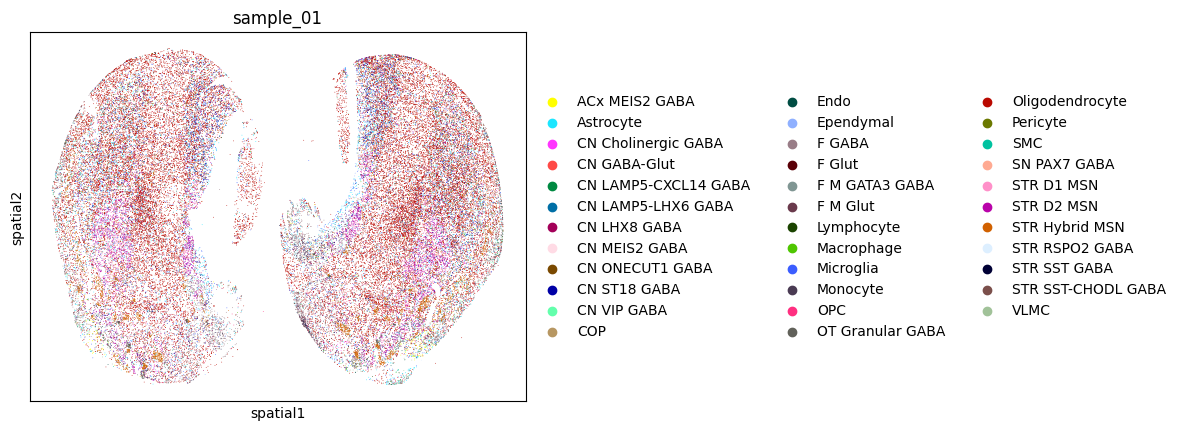

Sample: sample_02


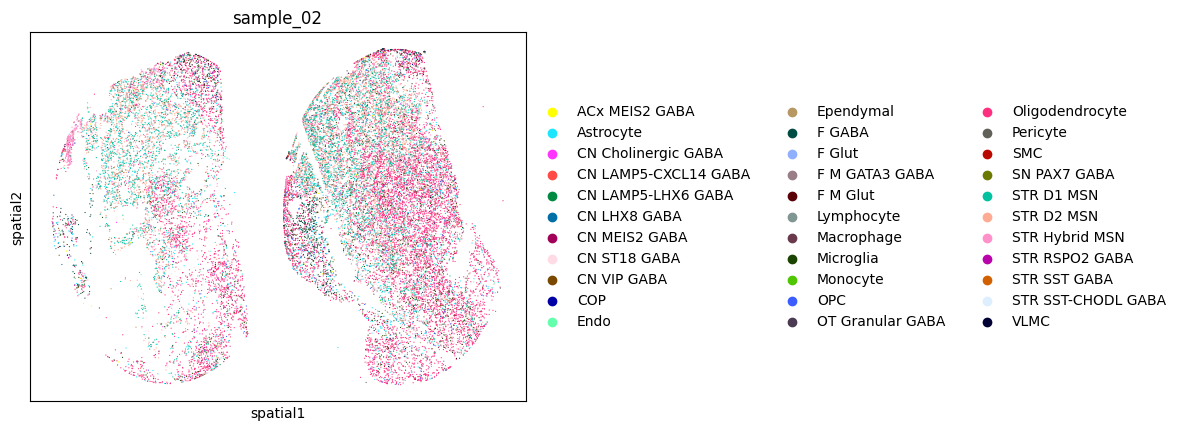

Sample: sample_03


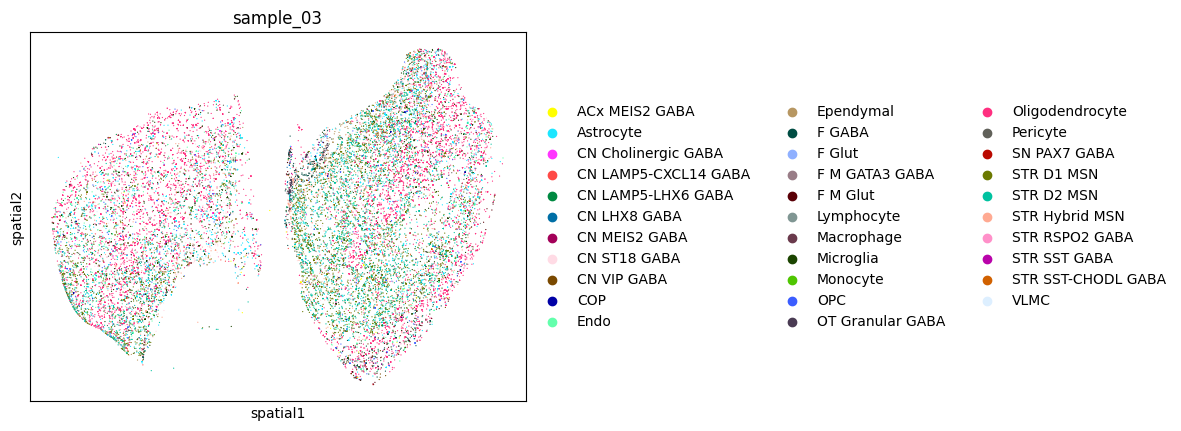

Sample: sample_04


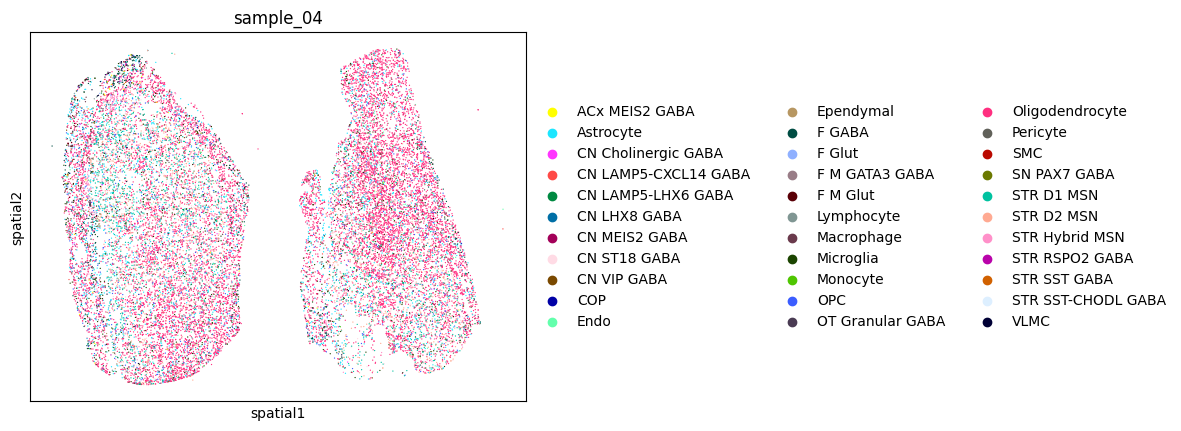

Sample: sample_05


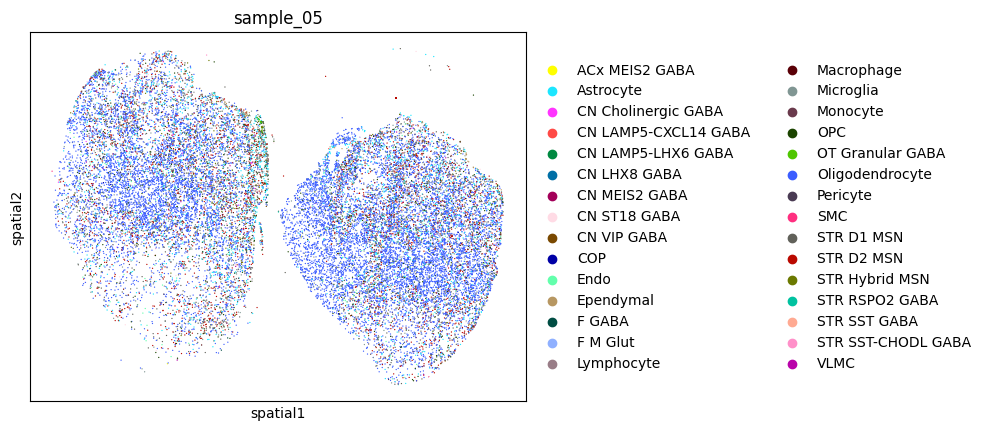

Sample: sample_06


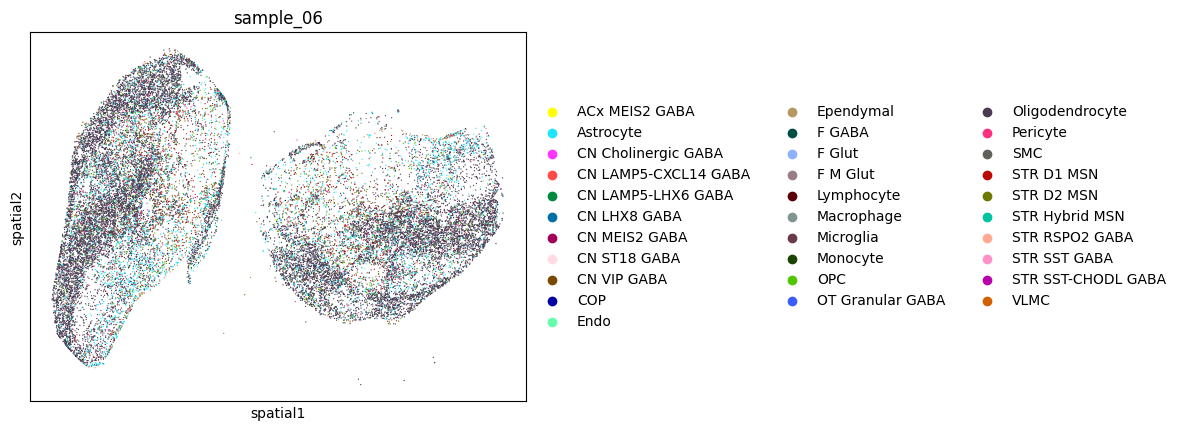

Sample: sample_07


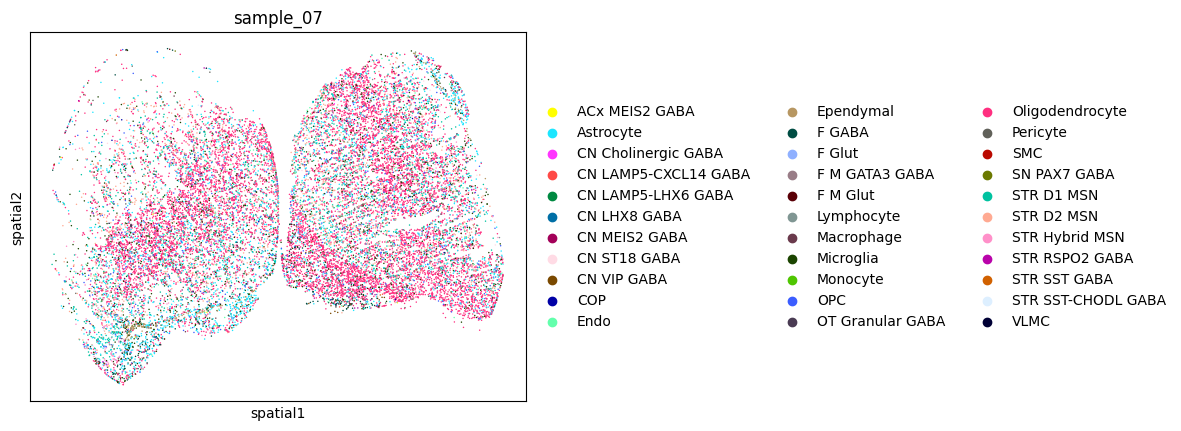

Sample: sample_08


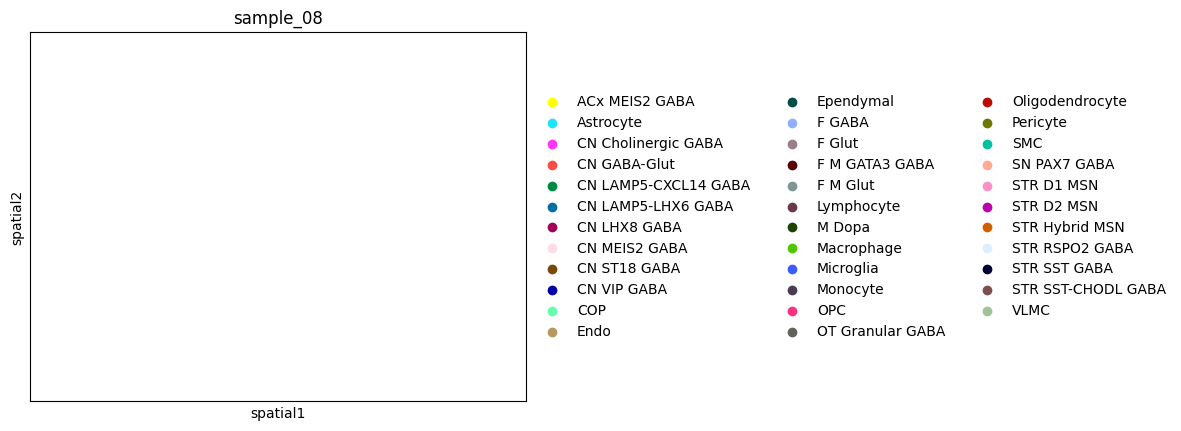

Sample: sample_09


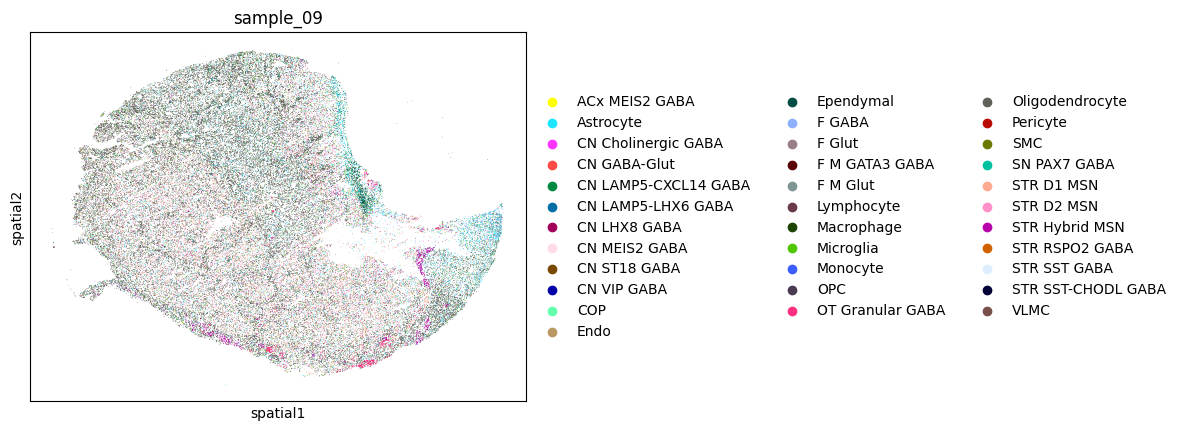

In [7]:
for s in adata.obs['sample'].unique():
    print(f"Sample: {s}")
    sc.pl.embedding(adata[adata.obs['sample'] == s].copy(), basis="spatial", color="Subclass_name", title=s)
    plt.show()

# ---
# ---
# ---

In [ ]:
adata = sc.read_h5ad(f'{BASE_PATH}/SlideTags_dataset/all_lib_adata.h5ad')

In [ ]:
import decoupler as dc
import scanpy as sc

genes = ['TAF1', 'OGT', 'MAPT']

# Pseudobulk over full adata so CPM is computed over all genes
pdata = dc.pp.pseudobulk(
    adata,
    sample_col='library_id',
    groups_col=None,
    layer="counts",
    mode='sum'
)

# Normalize to CPM over full transcriptome
sc.pp.normalize_total(pdata, target_sum=1e6)

pdata.var.index = pdata.var['gene_symbol'].astype(str).copy()
pdata.var_names_make_unique()

# Subset to genes of interest and merge metadata
cpm_df = pdata[:, genes].to_df()
cpm_df = cpm_df.merge(pdata.obs, left_index=True, right_on="library_id")
display(cpm_df)

cpm_df.to_csv(
    "/home/gdallagl/myworkdir/XDP/data/_old/SlideTags_XDP_pseudobulk_TAF1_OGT_MAPT_cpm.csv",
    index=False
)

,TAF1,OGT,MAPT,library_id,sample,donor_number,donor_id,condition,sex,age_at_onset,age_at_death,bcl,library,Sorted,psbulk_cells,psbulk_counts
251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1,80.299848,143.840767,296.327209,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H1,sample_01,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H1,Unsorted,30678.0,323051671.0
251027_SL-EXD_0706_A233KGFLT4_SI-TT-H2,79.471498,142.437524,293.718627,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H2,sample_01,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H2,Unsorted,29613.0,314804685.0
251027_SL-EXD_0706_A233KGFLT4_SI-TT-H3,65.302041,180.543122,244.605162,251027_SL-EXD_0706_A233KGFLT4_SI-TT-H3,sample_01,sample_01,SCF-18-003,diseased,male,32.0,41,251027_SL-EXD_0706_A233KGFLT4,SI-TT-H3,NeUN+,35118.0,430645041.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,63.899696,167.865231,330.593702,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B10,sample_02,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B10,Unsorted,10663.0,227575418.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,62.288801,169.872198,335.086853,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B11,sample_02,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B11,Unsorted,8614.0,171764423.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,63.843662,166.581178,347.987882,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-B12,sample_02,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-B12,Unsorted,8358.0,156554302.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,49.393028,209.411862,256.180010,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C1,sample_02,sample_02,SCF-20-025,diseased,male,51.0,58,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C1,NeUN+,14217.0,485736573.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C2,86.330551,207.877900,333.264655,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C2,sample_03,sample_03,SCF-19-014,diseased,male,30.0,32,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C2,Unsorted,21963.0,187268584.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C3,83.641025,211.510199,324.850050,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C3,sample_03,sample_03,SCF-19-014,diseased,male,30.0,32,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C3,Unsorted,3984.0,71854691.0
260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C4,90.840719,216.711242,376.617967,260313_SL-EXA_0758_B23GHNHLT4_SI-TT-C4,sample_03,sample_03,SCF-19-014,diseased,male,30.0,32,260313_SL-EXA_0758_B23GHNHLT4,SI-TT-C4,Unsorted,2488.0,47302576.0


TAF1     72.8
OGT     178.2
MAPT    295.6
dtype: float64


In [ ]:
# Mean CPM across all libraries
display(cpm_df[genes].mean().round(1))

# Mean CPM grouped by Sorted category
display(cpm_df.groupby("Sorted")[genes].mean().round(1))

TAF1     72.8
OGT     178.2
MAPT    295.6
dtype: float64

/tmp/ipykernel_1243307/2671352360.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(cpm_df.groupby("Sorted")[genes].mean().round(1))


,TAF1,OGT,MAPT
Sorted,,,
NeUN+,60.5,213.3,265.0
Unsorted,76.0,169.1,303.5
